Evaluating models on 26142 samples...

--- MODEL COMPARISON RESULTS ---
              Model  Accuracy  Precision  Recall  F1-Score    AUC
Logistic Regression    0.7204     0.7150  0.7329    0.7239 0.7658
      Decision Tree    0.6384     0.6357  0.6485    0.6420 0.6384
      Random Forest    0.7336     0.7171  0.7715    0.7433 0.8034
                SVM    0.7189     0.6969  0.7747    0.7337 0.7722
  Linear Regression    0.7218     0.7155  0.7364    0.7258 0.7655


ROC Curve plot successfully saved to ../reports/ROC_Curve_Comparison.png


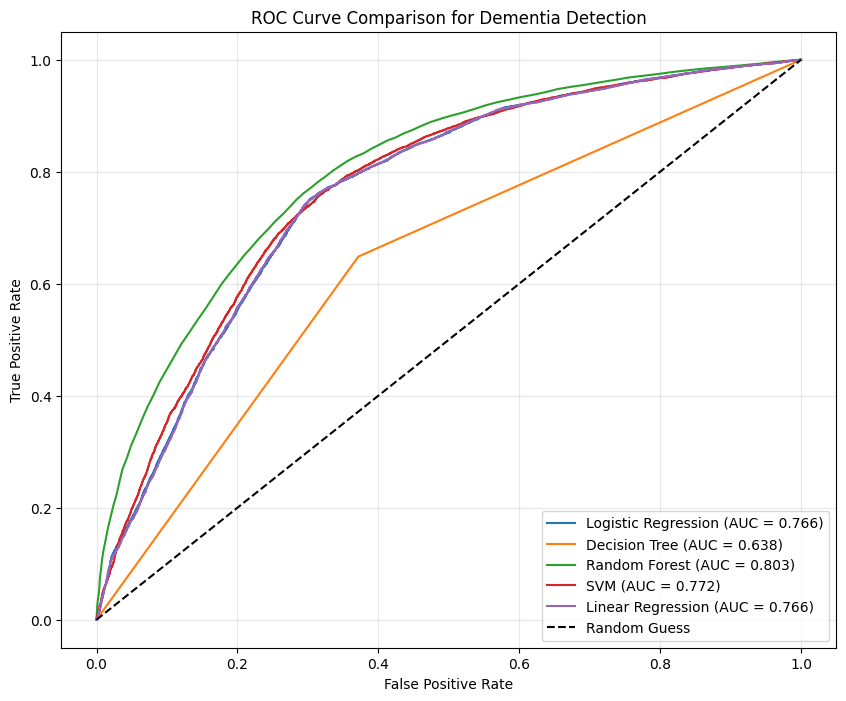

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 1. Load the Test Data (the 30% the models have never seen)
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')

print("Evaluating models on", X_test.shape[0], "samples...\n")

# 2. Ensure we have a folder to save our Chapter 4 charts
os.makedirs('../reports', exist_ok=True)

# 3. Define model names matching the saved files
model_names = ["Logistic_Regression", "Decision_Tree", "Random_Forest", "SVM", "Linear_Regression"]
results = []

# Set up the plot for the ROC Curve
plt.figure(figsize=(10, 8))

# 4. Evaluate each model
for name in model_names:
    model_path = '../models/' + name + '.pkl'
    model = joblib.load(model_path)
    
    # Make predictions
    if name == "Linear_Regression":
        # Linear Regression outputs continuous numbers. We threshold at 0.5 to make it a Yes(1) or No(0)
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        # We need the probabilities for the AUC-ROC curve
        y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    
    # Store results for the table
    results.append({
        "Model": name.replace("_", " "),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "AUC": round(auc, 4)
    })
    
    # Add to ROC plot
    label_text = name.replace("_", " ") + " (AUC = " + str(round(auc, 3)) + ")"
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=label_text)

# 5. Display the beautiful Results Table
results_df = pd.DataFrame(results)
print("--- MODEL COMPARISON RESULTS ---")
print(results_df.to_string(index=False))
print("\n")

# 6. Format and save the ROC plot (Ready for Chapter 4!)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Dementia Detection')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plot_path = '../reports/ROC_Curve_Comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print("ROC Curve plot successfully saved to", plot_path)

plt.show()